# Rainfall Forecasting with LSTM

This notebook trains an LSTM model to predict future rainfall, which will serve as a **World Model** for the RL environment.

**Architecture:**

- Multi-layer LSTM encoder
- Sequence-to-sequence prediction (predict next N days)
- Probabilistic output (mean + variance for uncertainty)

**Training Strategy:**

- Use historical sequences to predict future rainfall
- Train on all regions jointly (region embedding)
- Validate on held-out years


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

DATA_PROCESSED = Path('../data/processed')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cpu


In [ ]:
df = pd.read_csv(DATA_PROCESSED / 'rainfall_features_full.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Region', 'Date']).reset_index(drop=True)

print(f"Loaded {len(df):,} records")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Regions: {sorted(df['Region'].unique())}")

Loaded 67,570 records
Date range: 1983-01-01 to 2019-12-31
Regions: ['Region1', 'Region2', 'Region3', 'Region4', 'Region5']


In [ ]:


INPUT_FEATURES = [
    'Mean',
    
    'doy_sin', 'doy_cos', 'month_sin', 'month_cos',
    
    'rainfall_avg_7d', 'rainfall_avg_14d', 'rainfall_avg_30d',
    'rainfall_std_7d', 'rainfall_std_30d',
    'rainy_days_7d', 'rainy_days_30d',
    
    'clim_mean', 'rainfall_anomaly',
]

TARGET_COL = 'Mean'

missing = [f for f in INPUT_FEATURES if f not in df.columns]
if missing:
    print(f"Missing features: {missing}")
else:
    print(f"All {len(INPUT_FEATURES)} input features available")

All 14 input features available


In [ ]:
df_clean = df.dropna(subset=INPUT_FEATURES).copy()
print(f"Records after removing NaN: {len(df_clean):,} ({len(df_clean)/len(df)*100:.1f}%)")

Records after removing NaN: 67,570 (100.0%)


In [ ]:
SEQUENCE_LENGTH = 30  
FORECAST_HORIZON = 14  
BATCH_SIZE = 64 

In [ ]:
class RainfallSequenceDataset(Dataset):
    """
    Dataset for rainfall forecasting.
    Creates sliding windows of (input_sequence, target_sequence) pairs.
    """
    
    def __init__(self, data, input_features, target_col, 
                seq_length=30, forecast_horizon=14, region_col='Region'):
        self.seq_length = seq_length
        self.forecast_horizon = forecast_horizon
        self.input_features = input_features
        self.target_col = target_col
        
        self.sequences = []
        self.targets = []
        self.region_ids = []
        
        regions = sorted(data[region_col].unique())
        self.region_to_id = {r: i for i, r in enumerate(regions)}
        self.num_regions = len(regions)
        
        for region in regions:
            region_data = data[data[region_col] == region].sort_values('Date')
            
            X = region_data[input_features].values
            y = region_data[target_col].values
            
            # Create sliding windows
            total_window = seq_length + forecast_horizon
            for i in range(len(X) - total_window + 1):
                self.sequences.append(X[i:i+seq_length])
                self.targets.append(y[i+seq_length:i+total_window])
                self.region_ids.append(self.region_to_id[region])
        
        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.targets = np.array(self.targets, dtype=np.float32)
        self.region_ids = np.array(self.region_ids, dtype=np.int64)
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return {
            'sequence': torch.tensor(self.sequences[idx]),
            'target': torch.tensor(self.targets[idx]),
            'region_id': torch.tensor(self.region_ids[idx])
        }

In [ ]:
scaler = StandardScaler()
df_clean[INPUT_FEATURES] = scaler.fit_transform(df_clean[INPUT_FEATURES])

scaler_params = {
    'mean': scaler.mean_,
    'scale': scaler.scale_,
    'features': INPUT_FEATURES
}
np.save(MODELS_DIR / 'scaler_params.npy', scaler_params)

target_idx = INPUT_FEATURES.index(TARGET_COL)
target_mean = scaler.mean_[target_idx]
target_scale = scaler.scale_[target_idx]
print(f"Target '{TARGET_COL}' - mean: {target_mean:.4f}, scale: {target_scale:.4f}")

Target 'Mean' - mean: 0.0000, scale: 1.0000


In [ ]:
# Split by year for proper temporal validation
# Data spans 1983-2019 (37 years)
# Train: 1983-2014 (32 years, ~86%)
# Val:   2015-2017 (3 years, ~8%)
# Test:  2018-2019 (2 years, ~6%)

all_years = sorted(df_clean['Year'].unique())
print(f"Data years: {all_years[0]} to {all_years[-1]} ({len(all_years)} years)")

train_years = list(range(1983, 2015)) 
val_years = list(range(2015, 2018))   
test_years = list(range(2018, 2020))   

df_train = df_clean[df_clean['Year'].isin(train_years)]
df_val = df_clean[df_clean['Year'].isin(val_years)]
df_test = df_clean[df_clean['Year'].isin(test_years)]

print(f"Train: {len(df_train):,} records (years {train_years[0]}-{train_years[-1]}, {len(train_years)} years)")
print(f"Val:   {len(df_val):,} records (years {val_years[0]}-{val_years[-1]}, {len(val_years)} years)")
print(f"Test:  {len(df_test):,} records (years {test_years[0]}-{test_years[-1]}, {len(test_years)} years)")

Data years: 1983 to 2019 (37 years)
Train: 58,440 records (years 1983-2014, 32 years)
Val:   5,480 records (years 2015-2017, 3 years)
Test:  3,650 records (years 2018-2019, 2 years)


In [ ]:
train_dataset = RainfallSequenceDataset(
    df_train, INPUT_FEATURES, TARGET_COL,
    seq_length=SEQUENCE_LENGTH, forecast_horizon=FORECAST_HORIZON
)

val_dataset = RainfallSequenceDataset(
    df_val, INPUT_FEATURES, TARGET_COL,
    seq_length=SEQUENCE_LENGTH, forecast_horizon=FORECAST_HORIZON
)

test_dataset = RainfallSequenceDataset(
    df_test, INPUT_FEATURES, TARGET_COL,
    seq_length=SEQUENCE_LENGTH, forecast_horizon=FORECAST_HORIZON
)

print(f"Train sequences: {len(train_dataset):,}")
print(f"Val sequences:   {len(val_dataset):,}")
print(f"Test sequences:  {len(test_dataset):,}")

Train sequences: 58,225
Val sequences:   5,265
Test sequences:  3,435


In [17]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print(f"Batch shapes:")
print(f"  Sequence: {batch['sequence'].shape}")  # [batch, seq_len, features]
print(f"  Target:   {batch['target'].shape}")    # [batch, forecast_horizon]
print(f"  Region:   {batch['region_id'].shape}") # [batch]

Batch shapes:
  Sequence: torch.Size([64, 30, 14])
  Target:   torch.Size([64, 14])
  Region:   torch.Size([64])


In [18]:
class RainfallLSTM(nn.Module):
    """
    LSTM-based rainfall forecasting model.
    
    Features:
    - Region embedding for multi-region learning
    - Multi-layer LSTM encoder
    - Probabilistic output (predicts mean and log-variance)
    """
    
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, 
                num_regions=5, region_embed_dim=8,
                forecast_horizon=14, dropout=0.2):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.forecast_horizon = forecast_horizon
        
        self.region_embedding = nn.Embedding(num_regions, region_embed_dim)
        
        self.lstm = nn.LSTM(
            input_size=input_dim + region_embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )
        
        self.fc_mean = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, forecast_horizon)
        )
        
        self.fc_logvar = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, forecast_horizon)
        )
        
    def forward(self, x, region_ids):
        """
        Args:
            x: Input sequence [batch, seq_len, input_dim]
            region_ids: Region indices [batch]
            
        Returns:
            mean: Predicted rainfall mean [batch, forecast_horizon]
            logvar: Log-variance for uncertainty [batch, forecast_horizon]
        """
        batch_size, seq_len, _ = x.shape
        
        # Get region embeddings and expand to sequence length
        region_emb = self.region_embedding(region_ids)  # [batch, embed_dim]
        region_emb = region_emb.unsqueeze(1).expand(-1, seq_len, -1)  # [batch, seq_len, embed_dim]
        
        # Concatenate input with region embedding
        x = torch.cat([x, region_emb], dim=-1)  # [batch, seq_len, input_dim + embed_dim]
        
        # LSTM forward
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # Use last hidden state for prediction
        last_hidden = h_n[-1]  # [batch, hidden_dim]
        
        # Predict mean and log-variance
        mean = self.fc_mean(last_hidden)
        logvar = self.fc_logvar(last_hidden)
        
        return mean, logvar
    
    def predict(self, x, region_ids, num_samples=100):
        """
        Make probabilistic predictions with uncertainty.
        """
        self.eval()
        with torch.no_grad():
            mean, logvar = self.forward(x, region_ids)
            std = torch.exp(0.5 * logvar)
            
            # Sample from predicted distribution
            samples = torch.randn(num_samples, *mean.shape, device=mean.device)
            samples = mean.unsqueeze(0) + std.unsqueeze(0) * samples
            
            return {
                'mean': mean,
                'std': std,
                'samples': samples
            }

In [ ]:
MODEL_CONFIG = {
    'input_dim': len(INPUT_FEATURES),
    'hidden_dim': 128,
    'num_layers': 2,
    'num_regions': train_dataset.num_regions,
    'region_embed_dim': 8,
    'forecast_horizon': FORECAST_HORIZON,
    'dropout': 0.2
}

model = RainfallLSTM(**MODEL_CONFIG).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(model)

Total parameters: 228,292
Trainable parameters: 228,292

Model architecture:
RainfallLSTM(
  (region_embedding): Embedding(5, 8)
  (lstm): LSTM(22, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc_mean): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=14, bias=True)
  )
  (fc_logvar): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=14, bias=True)
  )
)


In [20]:
def gaussian_nll_loss(mean, logvar, target):
    """
    Gaussian Negative Log-Likelihood loss.
    Encourages accurate mean prediction and calibrated uncertainty.
    """
    var = torch.exp(logvar)
    loss = 0.5 * (logvar + (target - mean)**2 / var)
    return loss.mean()


def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    total_mse = 0
    
    for batch in loader:
        seq = batch['sequence'].to(device)
        target = batch['target'].to(device)
        region_ids = batch['region_id'].to(device)
        
        optimizer.zero_grad()
        
        mean, logvar = model(seq, region_ids)
        
        # Combined loss: NLL for probabilistic training + MSE for stability
        nll_loss = gaussian_nll_loss(mean, logvar, target)
        mse_loss = nn.functional.mse_loss(mean, target)
        loss = nll_loss + 0.1 * mse_loss
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        total_mse += mse_loss.item()
    
    return total_loss / len(loader), total_mse / len(loader)


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    total_mse = 0
    total_mae = 0
    
    with torch.no_grad():
        for batch in loader:
            seq = batch['sequence'].to(device)
            target = batch['target'].to(device)
            region_ids = batch['region_id'].to(device)
            
            mean, logvar = model(seq, region_ids)
            
            nll_loss = gaussian_nll_loss(mean, logvar, target)
            mse_loss = nn.functional.mse_loss(mean, target)
            mae_loss = nn.functional.l1_loss(mean, target)
            
            total_loss += (nll_loss + 0.1 * mse_loss).item()
            total_mse += mse_loss.item()
            total_mae += mae_loss.item()
    
    n = len(loader)
    return total_loss / n, total_mse / n, total_mae / n

In [ ]:
LEARNING_RATE = 1e-3
NUM_EPOCHS = 50
PATIENCE = 10   

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f"Training for {NUM_EPOCHS} epochs with early stopping (patience={PATIENCE})")

Training for 50 epochs with early stopping (patience=10)


In [ ]:
history = {'train_loss': [], 'val_loss': [], 'val_mse': [], 'val_mae': []}
best_val_loss = float('inf')
patience_counter = 0

print("Starting training...")
print("=" * 70)

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_mse = train_epoch(model, train_loader, optimizer, device)
    
    # Validate
    val_loss, val_mse, val_mae = evaluate(model, val_loader, device)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mse'].append(val_mse)
    history['val_mae'].append(val_mae)
    
    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'config': MODEL_CONFIG,
            'val_loss': val_loss,
            'scaler_params': scaler_params
        }, MODELS_DIR / 'rainfall_lstm_best.pt')
        marker = ' *'
    else:
        patience_counter += 1
        marker = ''
    
    lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val MSE: {val_mse:.4f} | "
        f"Val MAE: {val_mae:.4f} | "
        f"LR: {lr:.2e}{marker}")
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print("=" * 70)
print(f"Training complete. Best validation loss: {best_val_loss:.4f}")

Starting training...
Epoch   1/50 | Train Loss: 0.4640 | Val Loss: 0.4686 | Val MSE: 0.9081 | Val MAE: 0.7123 | LR: 1.00e-03 *
Epoch   2/50 | Train Loss: 0.4412 | Val Loss: 0.4663 | Val MSE: 0.9074 | Val MAE: 0.7106 | LR: 1.00e-03 *
Epoch   3/50 | Train Loss: 0.4235 | Val Loss: 0.4887 | Val MSE: 0.9135 | Val MAE: 0.7138 | LR: 1.00e-03
Epoch   4/50 | Train Loss: 0.3936 | Val Loss: 0.5212 | Val MSE: 0.9214 | Val MAE: 0.7112 | LR: 1.00e-03
Epoch   5/50 | Train Loss: 0.3516 | Val Loss: 0.5701 | Val MSE: 0.9331 | Val MAE: 0.7151 | LR: 1.00e-03
Epoch   6/50 | Train Loss: 0.3001 | Val Loss: 0.7512 | Val MSE: 0.9621 | Val MAE: 0.7251 | LR: 1.00e-03
Epoch   7/50 | Train Loss: 0.2489 | Val Loss: 0.6962 | Val MSE: 0.9538 | Val MAE: 0.7203 | LR: 1.00e-03
Epoch   8/50 | Train Loss: 0.1968 | Val Loss: 1.0622 | Val MSE: 0.9739 | Val MAE: 0.7171 | LR: 5.00e-04
Epoch   9/50 | Train Loss: 0.1256 | Val Loss: 1.3128 | Val MSE: 0.9914 | Val MAE: 0.7225 | LR: 5.00e-04
Epoch  10/50 | Train Loss: 0.0889 | Val

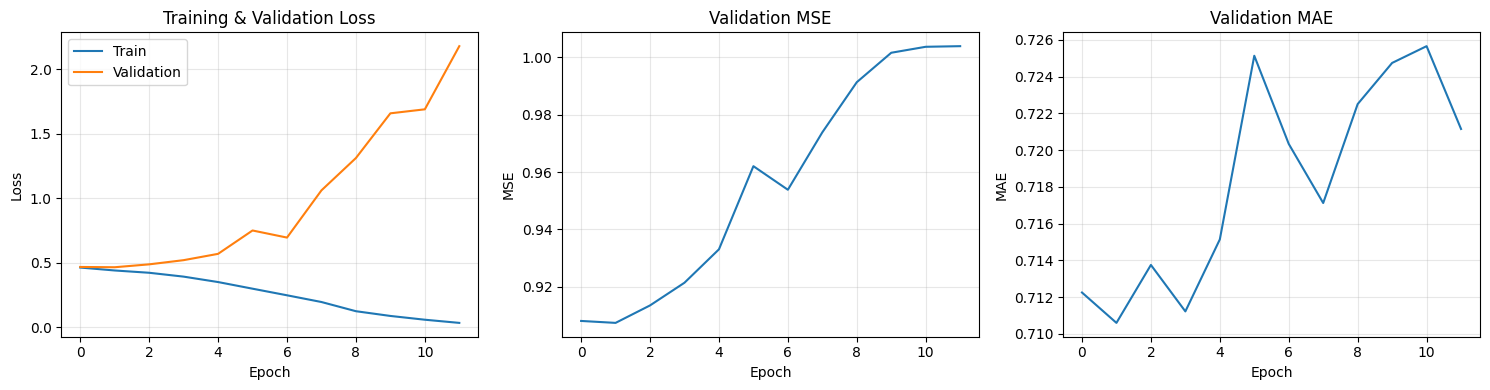

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MSE
axes[1].plot(history['val_mse'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].set_title('Validation MSE')
axes[1].grid(True, alpha=0.3)

# MAE
axes[2].plot(history['val_mae'])
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MAE')
axes[2].set_title('Validation MAE')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
checkpoint = torch.load(MODELS_DIR / 'rainfall_lstm_best.pt', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")

test_loss, test_mse, test_mae = evaluate(model, test_loader, device)
print(f"\nTest Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  MSE:  {test_mse:.4f}")
print(f"  MAE:  {test_mae:.4f}")

# Convert to original scale
test_mae_mm = test_mae * target_scale
test_rmse_mm = np.sqrt(test_mse) * target_scale
print(f"\nIn original scale (mm/day):")
print(f"  RMSE: {test_rmse_mm:.3f} mm")
print(f"  MAE:  {test_mae_mm:.3f} mm")

Loaded best model from epoch 2

Test Results:
  Loss: 0.6072
  MSE:  1.0327
  MAE:  0.7434

In original scale (mm/day):
  RMSE: 1.016 mm
  MAE:  0.743 mm


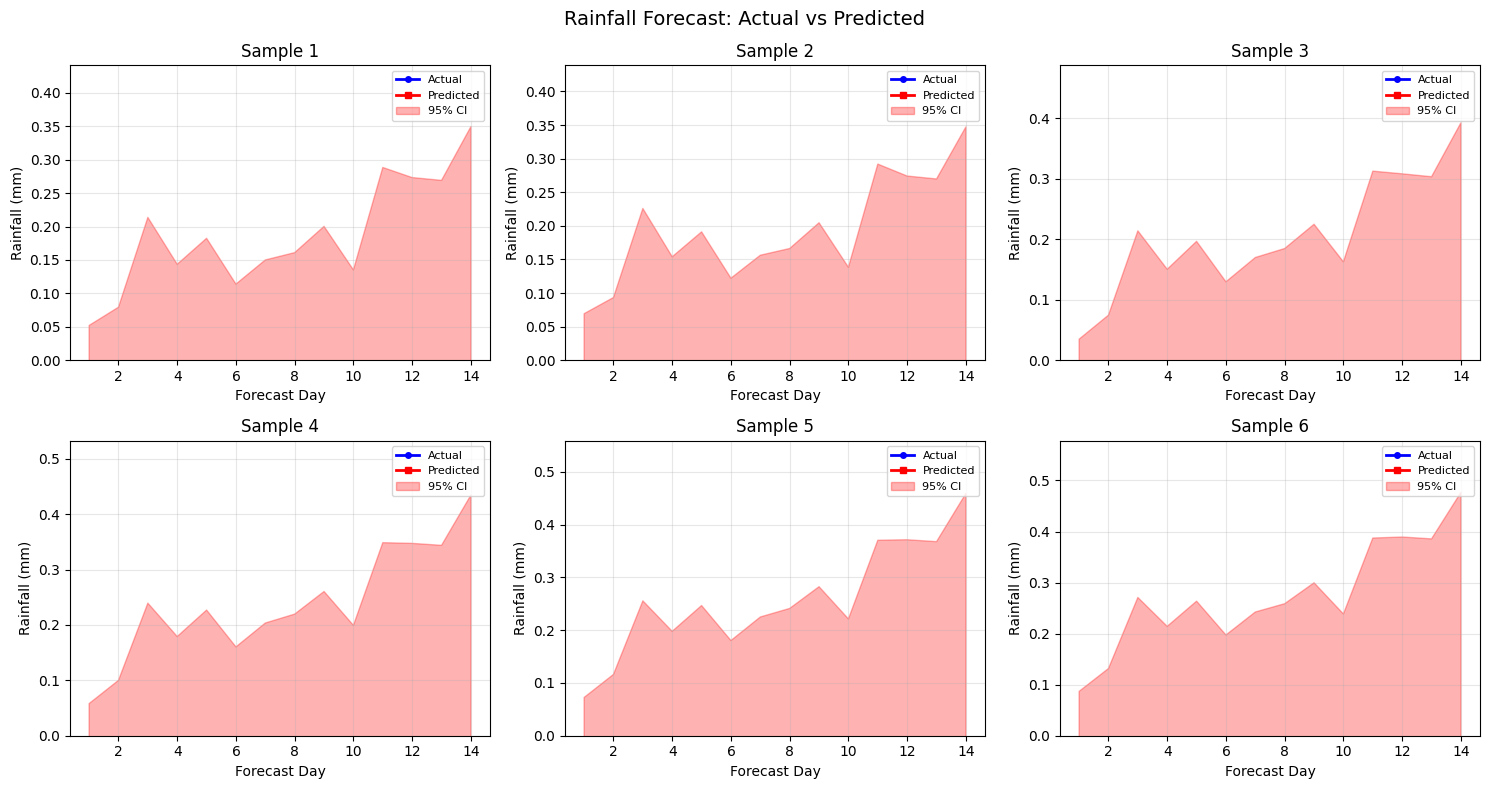

In [ ]:
model.eval()


batch = next(iter(test_loader))
seq = batch['sequence'].to(device)
target = batch['target'].cpu().numpy()
region_ids = batch['region_id'].to(device)

with torch.no_grad():
    pred_result = model.predict(seq, region_ids, num_samples=100)
    pred_mean = pred_result['mean'].cpu().numpy()
    pred_std = pred_result['std'].cpu().numpy()

# De-normalize
target = target * target_scale + target_mean
pred_mean = pred_mean * target_scale + target_mean
pred_std = pred_std * target_scale

# Plot a few examples
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    days = np.arange(1, FORECAST_HORIZON + 1)
    
    ax.plot(days, target[i], 'b-o', label='Actual', linewidth=2, markersize=4)
    ax.plot(days, pred_mean[i], 'r-s', label='Predicted', linewidth=2, markersize=4)
    ax.fill_between(days, 
                    pred_mean[i] - 2*pred_std[i], 
                    pred_mean[i] + 2*pred_std[i],
                    alpha=0.3, color='red', label='95% CI')
    
    ax.set_xlabel('Forecast Day')
    ax.set_ylabel('Rainfall (mm)')
    ax.set_title(f'Sample {i+1}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle('Rainfall Forecast: Actual vs Predicted', fontsize=14)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'forecast_examples.png', dpi=150, bbox_inches='tight')
plt.show()

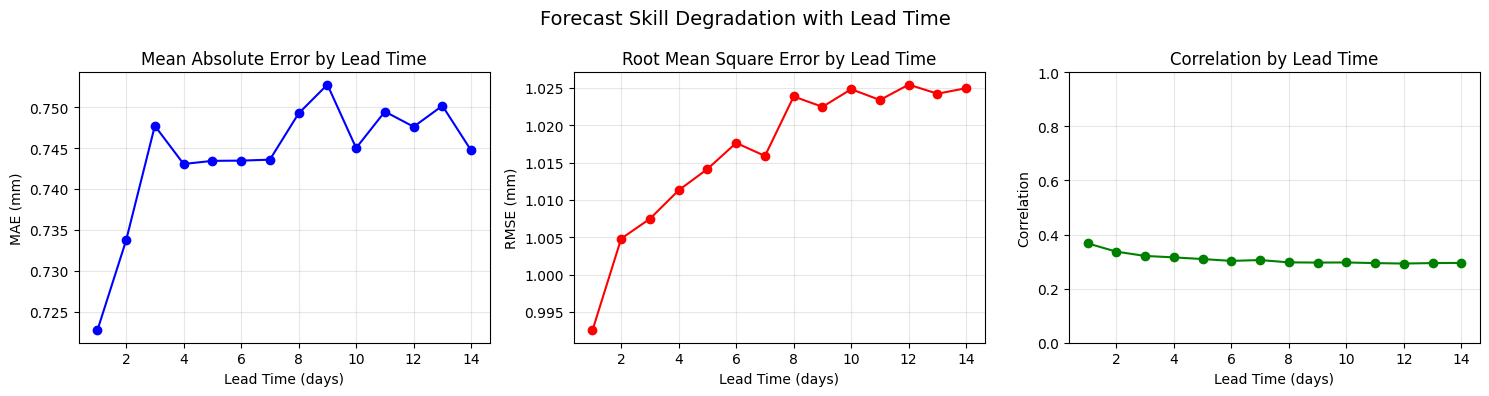


Forecast Skill Summary:
  Lead      MAE     RMSE     Corr
----------------------------------
     1    0.723    0.993    0.368
     2    0.734    1.005    0.337
     3    0.748    1.007    0.321
     4    0.743    1.011    0.316
     5    0.743    1.014    0.309
     6    0.743    1.018    0.303
     7    0.744    1.016    0.306
     8    0.749    1.024    0.297
     9    0.753    1.022    0.296
    10    0.745    1.025    0.297
    11    0.749    1.023    0.295
    12    0.748    1.025    0.293
    13    0.750    1.024    0.295
    14    0.745    1.025    0.295


In [ ]:
all_targets = []
all_predictions = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        seq = batch['sequence'].to(device)
        target = batch['target']
        region_ids = batch['region_id'].to(device)
        
        mean, _ = model(seq, region_ids)
        
        all_targets.append(target.numpy())
        all_predictions.append(mean.cpu().numpy())

all_targets = np.concatenate(all_targets, axis=0)
all_predictions = np.concatenate(all_predictions, axis=0)

# De-normalize
all_targets = all_targets * target_scale + target_mean
all_predictions = all_predictions * target_scale + target_mean

# Calculate metrics by lead time
mae_by_lead = []
rmse_by_lead = []
corr_by_lead = []

for lead in range(FORECAST_HORIZON):
    y_true = all_targets[:, lead]
    y_pred = all_predictions[:, lead]
    
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    
    mae_by_lead.append(mae)
    rmse_by_lead.append(rmse)
    corr_by_lead.append(corr)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

lead_days = np.arange(1, FORECAST_HORIZON + 1)

axes[0].plot(lead_days, mae_by_lead, 'b-o')
axes[0].set_xlabel('Lead Time (days)')
axes[0].set_ylabel('MAE (mm)')
axes[0].set_title('Mean Absolute Error by Lead Time')
axes[0].grid(True, alpha=0.3)

axes[1].plot(lead_days, rmse_by_lead, 'r-o')
axes[1].set_xlabel('Lead Time (days)')
axes[1].set_ylabel('RMSE (mm)')
axes[1].set_title('Root Mean Square Error by Lead Time')
axes[1].grid(True, alpha=0.3)

axes[2].plot(lead_days, corr_by_lead, 'g-o')
axes[2].set_xlabel('Lead Time (days)')
axes[2].set_ylabel('Correlation')
axes[2].set_title('Correlation by Lead Time')
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Forecast Skill Degradation with Lead Time', fontsize=14)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'forecast_skill_by_lead.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nForecast Skill Summary:")
print(f"{'Lead':>6} {'MAE':>8} {'RMSE':>8} {'Corr':>8}")
print("-" * 34)
for i in range(FORECAST_HORIZON):
    print(f"{i+1:>6} {mae_by_lead[i]:>8.3f} {rmse_by_lead[i]:>8.3f} {corr_by_lead[i]:>8.3f}")

In [1]:
class RainfallWorldModel:
    """
    Wrapper class for using the LSTM as a World Model in RL.
    Provides a simple interface for the RL environment.
    """
    
    def __init__(self, model_path, device='cpu'):
        self.device = torch.device(device)
        
        # Load checkpoint
        checkpoint = torch.load(model_path, map_location=self.device, weights_only=False)
        self.config = checkpoint['config']
        self.scaler_params = checkpoint['scaler_params']
        
        # Initialize model
        self.model = RainfallLSTM(**self.config).to(self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.eval()
        
        # Scaler info for target
        target_idx = self.scaler_params['features'].index('Mean')
        self.target_mean = self.scaler_params['mean'][target_idx]
        self.target_scale = self.scaler_params['scale'][target_idx]
        
    def predict(self, sequence, region_id, return_samples=False, num_samples=100):
        """
        Predict rainfall for next N days.
        
        Args:
            sequence: Input sequence [seq_len, features] (normalized)
            region_id: Region index (int)
            return_samples: If True, return Monte Carlo samples
            num_samples: Number of samples for uncertainty estimation
            
        Returns:
            Dictionary with 'mean', 'std', and optionally 'samples'
        """
        # Convert to tensor
        if isinstance(sequence, np.ndarray):
            sequence = torch.tensor(sequence, dtype=torch.float32)
        
        sequence = sequence.unsqueeze(0).to(self.device)  # Add batch dim
        region_tensor = torch.tensor([region_id], dtype=torch.long).to(self.device)
        
        with torch.no_grad():
            result = self.model.predict(sequence, region_tensor, num_samples)
            
            # De-normalize
            mean = result['mean'].squeeze(0).cpu().numpy()
            std = result['std'].squeeze(0).cpu().numpy()
            
            mean = mean * self.target_scale + self.target_mean
            std = std * self.target_scale
            
            output = {'mean': mean, 'std': std}
            
            if return_samples:
                samples = result['samples'].squeeze(1).cpu().numpy()
                samples = samples * self.target_scale + self.target_mean
                output['samples'] = samples
            
            return output
    
    def step(self, sequence, region_id):
        """
        Simulate one day forward (for RL environment).
        Returns sampled rainfall for the next day.
        """
        result = self.predict(sequence, region_id, return_samples=False)
        # Return prediction for day 1
        mean = result['mean'][0]
        std = result['std'][0]
        
        # Sample from predicted distribution
        rainfall = max(0, np.random.normal(mean, std))
        return rainfall, {'mean': mean, 'std': std}

In [ ]:
world_model = RainfallWorldModel(MODELS_DIR / 'rainfall_lstm_best.pt', device=str(device))

batch = next(iter(test_loader))
test_seq = batch['sequence'][0].numpy()
test_region = batch['region_id'][0].item()

# Make prediction
prediction = world_model.predict(test_seq, test_region)
print(f"Forecast for Region {test_region}:")
print(f"  Mean: {prediction['mean']}")
print(f"  Std:  {prediction['std']}")

# Simulate one step
rainfall, info = world_model.step(test_seq, test_region)
print(f"\nSimulated next-day rainfall: {rainfall:.2f} mm")

Forecast for Region 0:
  Mean: [-0.67893451 -0.65628588 -0.60791487 -0.62690657 -0.63710684 -0.63529009
 -0.62647289 -0.62967658 -0.61513615 -0.65392345 -0.58952749 -0.59859741
 -0.60795754 -0.56270039]
  Std:  [0.36547139 0.36780655 0.41079521 0.38521454 0.40975899 0.37459698
 0.38824052 0.39532539 0.40769395 0.39452472 0.43893492 0.43590599
 0.43849707 0.45603424]

Simulated next-day rainfall: 0.00 mm
